In [1]:
# 1. 라이브러리 + 경로 설정
import os
import sys
sys.path.append(os.path.abspath(".."))

import pandas as pd
import joblib
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer

# 모듈 가져오기
from src.preprocessing import preprocess_dataframe
from src.model import train_model, save_model
from src.evaluation import evaluate_model

In [2]:
# 2. 데이터 로드 + 전처리
df = pd.read_csv('../data/Reviews.csv')
df = preprocess_dataframe(df)
X, y = df['Text'], df['Sentiment']

In [3]:
# 3. train-test 분리
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [4]:
# 4. 벡터화
tfidf = TfidfVectorizer(max_features=2000, ngram_range=(1,2), stop_words='english')
X_train_vec = tfidf.fit_transform(X_train)
X_test_vec = tfidf.transform(X_test)

# 저장 (선택)
joblib.dump(tfidf, '../outputs/vectorizer_rf.pkl')

['../outputs/vectorizer_rf.pkl']

In [5]:
# 5. 모델 학습 + 저장
rf = train_model(X_train_vec, y_train, model_type='rf', class_weight='balanced', n_estimators=20)
save_model(rf, '../outputs/models/randomforest_balanced.pkl')


==== Random Forest + Balanced ====
              precision    recall  f1-score   support

           0       0.92      0.67      0.77     16407
           1       0.94      0.99      0.96     88756

    accuracy                           0.94    105163
   macro avg       0.93      0.83      0.87    105163
weighted avg       0.94      0.94      0.94    105163

ROC AUC: 0.9701


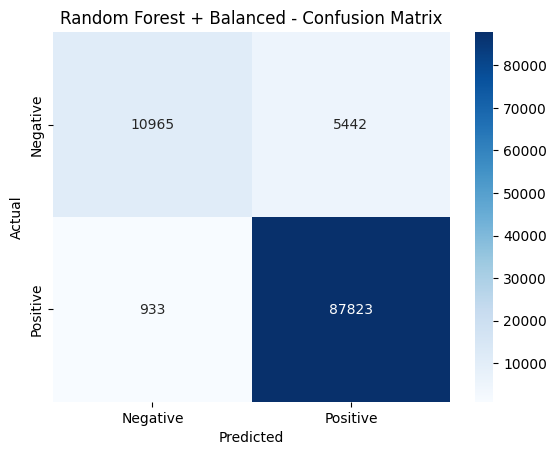

In [6]:
# 6. 평가
evaluate_model("Random Forest + Balanced", rf, X_test_vec, y_test)